In [1]:
from datasets import load_dataset


# Data Collection

## Data Candidates

https://huggingface.co/datasets/Enlightir/ai-vs-human-combined

+ (+) Most recently updated
+ (+) \> 500,000 entries
- (-) Author page/site is relatively blank or un-informative
- (-) No `readme` on data sources or verification of AI/human source

https://huggingface.co/datasets/Samambas/Human_vs_AI_Portuguese

+ (+) Foreign language, good to test with later
- (-) Same issues as above

https://huggingface.co/datasets/ahmadreza13/human-vs-Ai-generated-dataset

+ (+) Labels my model generated with
- (-) Similar data sourcing issues

https://huggingface.co/datasets/ilyasoulk/ai-vs-human-meta-llama-Llama-3.1-8B-Instruct-CNN / https://huggingface.co/datasets/zcamz/ai-vs-human-google-gemma-2-2b-it

+ (-) Datasets with specific models, good for later comparisons 
- (-) Relatively smaller

---

I think for now it's best to move forward with the `ahmadreza13/human-vs-Ai-generated-dataset` dataset - it's good that it labels by model, but it seems like mostly wikipedia. That might cause issues! But if those pop up in testing, come back here and change the tuning dataset!

In [2]:

dataset = load_dataset("ahmadreza13/human-vs-Ai-generated-dataset")

In [3]:
print("Models/sources:", set(dataset['train']['model'][:]))

Models/sources: {'GPT4', 'Claude3-Opus', 'wikipedia', 'claude', 'gemini-1.5-pro'}


In [4]:
print("Shape of training dataset:", dataset['train'].shape)


Shape of training dataset: (3614247, 3)


In [5]:
dataset['train'].column_names

['data', 'generated', 'model']

<Axes: >

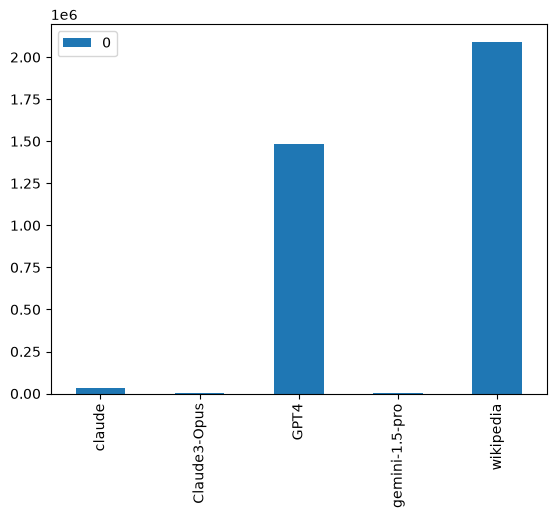

In [ ]:
import pandas
from collections import Counter

# plot a distribution of the number of counts of each source in the dataset

df = pandas.DataFrame.from_dict(Counter(dataset['train']['model'][:]), orient='index')
df.plot(kind='bar')


<Axes: >

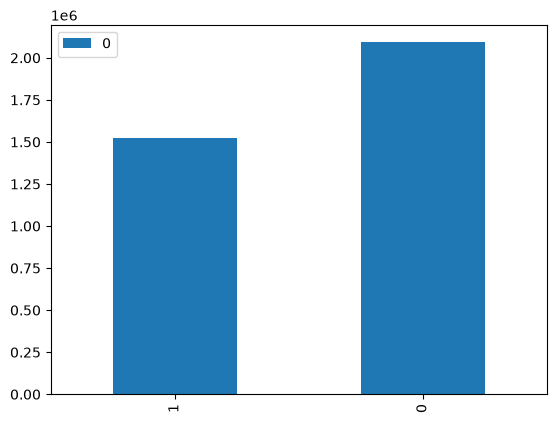

In [ ]:
# now check total no. of generated vs human data

df = pandas.DataFrame.from_dict(Counter(dataset['train']['generated'][:]), orient='index')
df.plot(kind='bar')


In [ ]:
# try checking, e.g., all wikipedia data is human. first, filter: 

temp = dataset['train']
temp = temp.filter(lambda example: example['model'] == 'wikipedia')

<Axes: >

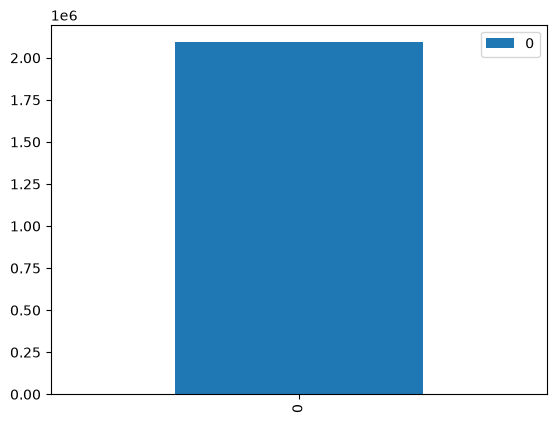

In [ ]:
# then count and plot

temp = temp['generated'][:]
counts = Counter(temp)

df = pandas.DataFrame.from_dict(counts, orient='index')
df.plot(kind='bar')


In [ ]:
# testing if counter works without slicing the dataset and loading all into mem
Counter(dataset['train']['model'])

Counter({'wikipedia': 2092358,
         'GPT4': 1484502,
         'claude': 32170,
         'Claude3-Opus': 4217,
         'gemini-1.5-pro': 1000})

In [ ]:
# try with pandas instead; faster!
dataset['train'].remove_columns('data').to_pandas().value_counts()

generated  model         
0          wikipedia         2092358
1          GPT4              1484502
           claude              32170
           Claude3-Opus         4217
           gemini-1.5-pro       1000
Name: count, dtype: int64

In [ ]:
# check features
dataset['train'].features

{'data': Value('string'),
 'generated': Value('int64'),
 'model': Value('string')}

In [43]:
# now just get a final no. of human vs ai to compare to
generated_counts = dataset['train'].remove_columns(['data', 'model']).to_pandas().value_counts()
generated_counts

generated
0            2092358
1            1521889
Name: count, dtype: int64

In [47]:
human_counts, ai_counts = generated_counts[0], generated_counts[1]
percentage_human = human_counts / (human_counts + ai_counts) * 100
print(f"Percentage of human data: {percentage_human:.2f}%")

Percentage of human data: 57.89%
